# 🔗 Lesson 03 · Prompt 链式工作流

> **多步串行**：先生成大纲，再按大纲写正文——在图上显式串起来。

本课你会学到：
- 用多条边表达 Prompt 链（顺序依赖）
- 后节点如何读取前节点写入的 `outline`
- 链式 = 多节点 + 直连边，而不是一个巨型 Prompt

模型：**DeepSeek V4 Pro**（`deepseek-v4-pro`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart LR
    S([START]) --> O[create_outline]
    O --> B[create_blog]
    B --> E([END])


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class O,B llm
    class E output
```


**要点：** 后节点依赖前节点写入的 `outline`；链式 = 多边顺序。



# 导入

引入 LangGraph、ChatOpenAI、TypedDict 与 dotenv。


In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


# 加载环境变量

从 `.env` 读取 `DEEPSEEK_API_KEY` 等配置。


In [2]:
load_dotenv()

True

# 定义 LLM

用 DeepSeek OpenAI 兼容接口创建 ChatOpenAI。

**注意：** `deepseek-v4-pro` 默认开启 thinking；非流式会等完整推理才返回，链式两步很容易“一直转圈”。本课演示关闭 thinking，并设置 `timeout` / `max_tokens`。


In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

# deepseek-v4-pro 默认开启 thinking；非流式会等完整推理才返回，链式两步很容易“卡住”。
# 教学演示关闭 thinking；需要推理时再改成 {"type": "enabled"}。
model = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,          # 单次请求超时（秒）
    max_tokens=1200,      # 限制输出长度，避免长文拖很久
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)



# 定义 State

链式字段：主题 → 大纲 → 正文。


In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

# 创建节点

`create_outline` 写大纲，`create_blog` 按大纲写正文。


In [5]:
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]
    print(f"[1/2] create_outline ← {title!r}")

    prompt = (
        f"请用中文为博客主题「{title}」生成一份简洁大纲，"
        "不超过 8 个一级要点，每个要点一行。"
    )
    outline = model.invoke(prompt).content
    print("[1/2] create_outline ✓")

    state["outline"] = outline
    return state


In [6]:
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]
    print(f"[2/2] create_blog ← 基于大纲写短文")

    prompt = (
        f"请用中文根据下列大纲，写一篇约 300 字的短博客，主题是「{title}」。\n"
        f"大纲：\n{outline}"
    )
    content = model.invoke(prompt).content
    print("[2/2] create_blog ✓")

    state["content"] = content
    return state


# 定义与编译图

START → create_outline → create_blog → END。


In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


# 执行图

传入主题，跑完整条 Prompt 链。


In [8]:
initial_state = {"title": "小学时是否需要学AI"}

final_state = workflow.invoke(initial_state)

print("keys:", list(final_state.keys()))
print("--- outline ---")
print(final_state["outline"])
print("--- content ---")
print(final_state["content"])


[1/2] create_outline ← '小学时是否需要学AI'
[1/2] create_outline ✓
[2/2] create_blog ← 基于大纲写短文
[2/2] create_blog ✓
keys: ['title', 'outline', 'content']
--- outline ---
以下是关于“小学时是否需要学AI”的博客大纲：

- **时代背景：AI素养已成为数字时代的“新常识”**
- **认知发展：小学阶段是培养计算思维与好奇心的黄金窗口**
- **目标定位：重在“理解与驾驭”，而非“算法与编程”**
- **核心能力：从数据意识、逻辑思维到人机协作的启蒙**
- **跨学科融合：AI不是独立学科，而是连接各科知识的纽带**
- **伦理与安全：从小建立对深度伪造、隐私保护的辨别力**
- **减负而非增负：警惕技术焦虑，避免落入新的“军备竞赛”**
- **落地路径：通过游戏化、项目式学习实现“无痛”入门**
--- content ---
小学阶段是否需要学AI？我的答案是：不仅要，而且要聪明地学。

我们正身处一个AI素养逐渐成为“新常识”的时代。就像当年学打字和上网一样，理解AI不再是选修课，而是数字生存的刚需。小学时期恰恰是培养计算思维与好奇心的黄金窗口，孩子们天然爱问“为什么”，这正是理解机器如何学习的绝佳起点。

但请别误会，这绝不是要把小学生都培养成程序员。目标定位应当是“理解与驾驭”，而非死磕算法。核心在于启蒙数据意识、逻辑思维，以及学会如何与AI高效协作。AI更像是一条跨学科融合的纽带，能把数学的逻辑、语文的表达、美术的创意串联起来，让知识变得鲜活。

更紧迫的是伦理与安全。孩子需要尽早建立对深度伪造和隐私泄露的辨别力，知道屏幕背后的信息未必真实。当然，我们必须警惕技术焦虑，避免让AI成为新的“军备竞赛”和负担。最好的落地路径是游戏化、项目式的“无痛”入门，让孩子在玩中思考，在创造中减负，真正成为技术的主人。


In [9]:
import json
print(json.dumps(final_state, ensure_ascii=False, indent=2))

{
  "title": "小学时是否需要学AI",
  "outline": "以下是关于“小学时是否需要学AI”的博客大纲：\n\n- **时代背景：AI素养已成为数字时代的“新常识”**\n- **认知发展：小学阶段是培养计算思维与好奇心的黄金窗口**\n- **目标定位：重在“理解与驾驭”，而非“算法与编程”**\n- **核心能力：从数据意识、逻辑思维到人机协作的启蒙**\n- **跨学科融合：AI不是独立学科，而是连接各科知识的纽带**\n- **伦理与安全：从小建立对深度伪造、隐私保护的辨别力**\n- **减负而非增负：警惕技术焦虑，避免落入新的“军备竞赛”**\n- **落地路径：通过游戏化、项目式学习实现“无痛”入门**",
  "content": "小学阶段是否需要学AI？我的答案是：不仅要，而且要聪明地学。\n\n我们正身处一个AI素养逐渐成为“新常识”的时代。就像当年学打字和上网一样，理解AI不再是选修课，而是数字生存的刚需。小学时期恰恰是培养计算思维与好奇心的黄金窗口，孩子们天然爱问“为什么”，这正是理解机器如何学习的绝佳起点。\n\n但请别误会，这绝不是要把小学生都培养成程序员。目标定位应当是“理解与驾驭”，而非死磕算法。核心在于启蒙数据意识、逻辑思维，以及学会如何与AI高效协作。AI更像是一条跨学科融合的纽带，能把数学的逻辑、语文的表达、美术的创意串联起来，让知识变得鲜活。\n\n更紧迫的是伦理与安全。孩子需要尽早建立对深度伪造和隐私泄露的辨别力，知道屏幕背后的信息未必真实。当然，我们必须警惕技术焦虑，避免让AI成为新的“军备竞赛”和负担。最好的落地路径是游戏化、项目式的“无痛”入门，让孩子在玩中思考，在创造中减负，真正成为技术的主人。"
}


In [10]:
print(final_state['outline'])

以下是关于“小学时是否需要学AI”的博客大纲：

- **时代背景：AI素养已成为数字时代的“新常识”**
- **认知发展：小学阶段是培养计算思维与好奇心的黄金窗口**
- **目标定位：重在“理解与驾驭”，而非“算法与编程”**
- **核心能力：从数据意识、逻辑思维到人机协作的启蒙**
- **跨学科融合：AI不是独立学科，而是连接各科知识的纽带**
- **伦理与安全：从小建立对深度伪造、隐私保护的辨别力**
- **减负而非增负：警惕技术焦虑，避免落入新的“军备竞赛”**
- **落地路径：通过游戏化、项目式学习实现“无痛”入门**


In [11]:
print(final_state['content'])

小学阶段是否需要学AI？我的答案是：不仅要，而且要聪明地学。

我们正身处一个AI素养逐渐成为“新常识”的时代。就像当年学打字和上网一样，理解AI不再是选修课，而是数字生存的刚需。小学时期恰恰是培养计算思维与好奇心的黄金窗口，孩子们天然爱问“为什么”，这正是理解机器如何学习的绝佳起点。

但请别误会，这绝不是要把小学生都培养成程序员。目标定位应当是“理解与驾驭”，而非死磕算法。核心在于启蒙数据意识、逻辑思维，以及学会如何与AI高效协作。AI更像是一条跨学科融合的纽带，能把数学的逻辑、语文的表达、美术的创意串联起来，让知识变得鲜活。

更紧迫的是伦理与安全。孩子需要尽早建立对深度伪造和隐私泄露的辨别力，知道屏幕背后的信息未必真实。当然，我们必须警惕技术焦虑，避免让AI成为新的“军备竞赛”和负担。最好的落地路径是游戏化、项目式的“无痛”入门，让孩子在玩中思考，在创造中减负，真正成为技术的主人。


# 可视化图结构（可选）

画出链式节点与边。


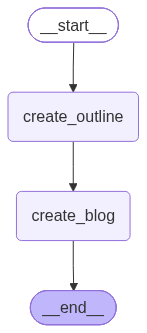

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())